# Projet — Détection de faux profils


In [78]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.paths import DATA_RAW, DATA_PROCESSED, MODELS_DIR

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("OK — Racine projet :", ROOT)
print("Données brutes :", DATA_RAW)

OK — Racine projet : c:\Users\treso\Documents\esme\INGE 2\machine learning\projet\fakes-account
Données brutes : C:\Users\treso\Documents\esme\INGE 2\machine learning\projet\fakes-account\data\raw


## 1 — Charger les données 

In [79]:
import pandas as pd

df = pd.read_csv(r'..\data\raw\twitter_human_bots_dataset.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37438 entries, 0 to 37437
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     37438 non-null  int64  
 1   created_at                     37438 non-null  str    
 2   default_profile                37438 non-null  bool   
 3   default_profile_image          37438 non-null  bool   
 4   description                    30181 non-null  str    
 5   favourites_count               37438 non-null  int64  
 6   followers_count                37438 non-null  int64  
 7   friends_count                  37438 non-null  int64  
 8   geo_enabled                    37438 non-null  bool   
 9   id                             37438 non-null  int64  
 10  lang                           29481 non-null  str    
 11  location                       37434 non-null  str    
 12  profile_background_image_url   32939 non-null  str    
 1

### 1.1 type d'informations


In [80]:
df.dtypes


Unnamed: 0                         int64
created_at                           str
default_profile                     bool
default_profile_image               bool
description                          str
favourites_count                   int64
followers_count                    int64
friends_count                      int64
geo_enabled                         bool
id                                 int64
lang                                 str
location                             str
profile_background_image_url         str
profile_image_url                    str
screen_name                          str
statuses_count                     int64
verified                            bool
average_tweets_per_day           float64
account_age_days                   int64
account_type                         str
profile_image_path                   str
profile_background_image_path        str
split                              int64
dtype: object

In [81]:
df['account_type'].value_counts()

account_type
human    25013
bot      12425
Name: count, dtype: int64

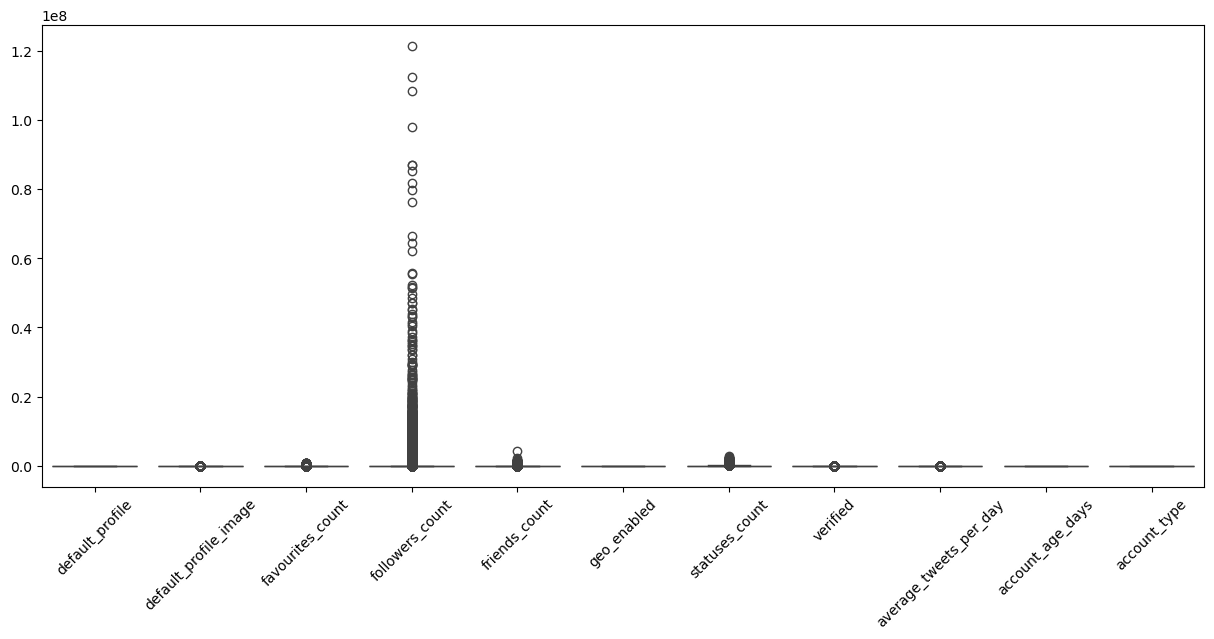

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

### 1.2 Valeurs manquantes et doublons

In [84]:
manquants = df.isna().sum()
print("Total NaN par colonne :")
print(manquants[manquants > 0])
print("\nTotal de cellules NaN :", df.isna().sum().sum())

dups = df.duplicated().sum()
print("\nLignes en double (toutes colonnes) :", dups)

Total NaN par colonne :
description                       7257
lang                              7957
location                             4
profile_background_image_url      4499
profile_image_url                    1
profile_image_path               12938
profile_background_image_path    12938
dtype: int64

Total de cellules NaN : 45594

Lignes en double (toutes colonnes) : 0


### 1.3 Nettoyage de la base de données

In [85]:
from sklearn.preprocessing import LabelEncoder

cols_drop = ['Unnamed: 0', 'id', 'created_at', 'screen_name',
             'profile_background_image_url', 'profile_image_url',
             'profile_image_path', 'profile_background_image_path', 'split', 'description',
             'location','lang']
df = df.drop(columns=cols_drop)

df['account_type'] = (df['account_type'] == 'bot').astype(int)

def categorical_features(df):
    object_columns = df.select_dtypes(include='object').columns
    label_encoder = LabelEncoder()
    for col in object_columns:
        df[col] = df[col].fillna('unknown')
        df[col] = label_encoder.fit_transform(df[col])
    return df

df = categorical_features(df)
df = df.fillna(df.median(numeric_only=True))

Split des features et de la base de donnée

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('account_type', axis=1)
y = df['account_type']
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(X)
print(y)

       default_profile  default_profile_image  favourites_count  \
0                False                  False              5007   
1                False                  False              1038   
2                False                  False              2257   
3                False                  False              6407   
4                False                  False             20866   
...                ...                    ...               ...   
37433            False                  False             59660   
37434            False                  False                 0   
37435            False                  False                28   
37436             True                  False               621   
37437            False                  False              4526   

       followers_count  friends_count  geo_enabled  statuses_count  verified  \
0                  102            168        False            3974     False   
1                   60            1

### 1.4 Matrice de corrélation

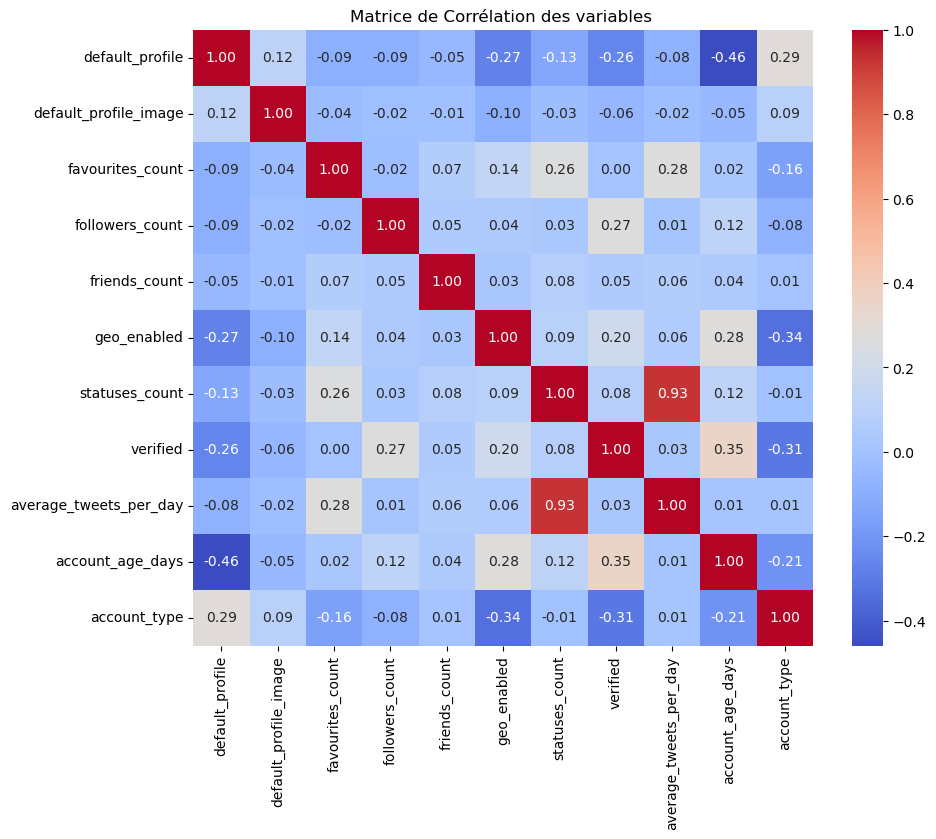

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des variables ")
plt.show()

---
Recherche des features importants

                        importance
followers_count           0.216758
favourites_count          0.195913
friends_count             0.159422
statuses_count            0.132400
account_age_days          0.113695
average_tweets_per_day    0.105724
geo_enabled               0.031185
verified                  0.029118
default_profile           0.013582
default_profile_image     0.002202


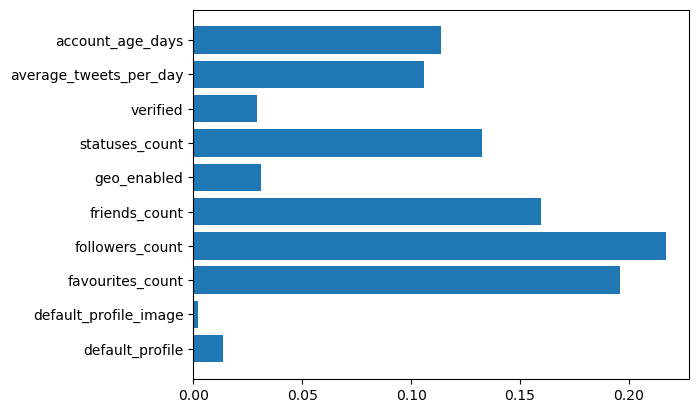

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf1 = RandomForestClassifier(n_estimators=100)
rf1.fit(X_train, y_train)
y_pred = rf1.predict(X_test)

featureimpor = pd.DataFrame(rf1.feature_importances_, index=X_train.columns,
              columns=["importance"]).sort_values("importance", ascending=False)
print(featureimpor)
plt.barh(X_train.columns, rf1.feature_importances_)
plt.show()

Suppression des features non important de la base

In [89]:
threshold = 0.01
cols_impor = featureimpor[featureimpor["importance"] > threshold].index
X = X[cols_impor]
X_train = X_train[cols_impor]
X_test = X_test[cols_impor]

print(X)

       followers_count  favourites_count  friends_count  statuses_count  \
0                  102              5007            168            3974   
1                   60              1038            128             259   
2                  599              2257            449           13627   
3                  116              6407            334            4432   
4                74448             20866             18           15870   
...                ...               ...            ...             ...   
37433           257294             59660            196           58680   
37434            74666                 0             95           41240   
37435           255941                28            236            6692   
37436          2678042               621             51            2042   
37437           471451              4526          15967           11597   

       account_age_days  average_tweets_per_day  geo_enabled  verified  \
0                  4063  

In [90]:
import joblib
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")
print("Scaler sauvegardé dans models/")

Scaler sauvegardé dans models/


---
## 3 — Entraînement des modèles

Entraîner régression logistique, KNN, arbre, Random Forest, AdaBoost, sauvegarder avec `joblib` dans `models/`.

---

**Modèle 1 : Arbre de décision**

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

params = [{"max_depth": 3}, {"max_depth": 5}, {"max_depth": 10}, {"max_depth": 15}]

for p in params:
    dt = DecisionTreeClassifier(**p, random_state=42)
    dt.fit(X_train_scaled, y_train)
    acc_train = accuracy_score(y_train, dt.predict(X_train_scaled))
    acc_test  = accuracy_score(y_test,  dt.predict(X_test_scaled))
    print(f"max_depth={p['max_depth']} : Train: {acc_train:.4f} | Test: {acc_test:.4f}")

max_depth=3 : Train: 0.8065 | Test: 0.8048
max_depth=5 : Train: 0.8303 | Test: 0.8265
max_depth=10 : Train: 0.8976 | Test: 0.8603
max_depth=15 : Train: 0.9509 | Test: 0.8504


In [92]:
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print("Arbre de Décision")
print("Accuracy:",  accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:",    recall_score(y_test, y_pred_dt))
print("F1-Score:",  f1_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

joblib.dump(dt, MODELS_DIR / "decision_tree.joblib")
print("Modèle sauvegardé dans models/")

Arbre de Décision
Accuracy: 0.8603098290598291
Precision: 0.8221307727480567
Recall: 0.7323828920570264
F1-Score: 0.7746660922016372
[[4644  389]
 [ 657 1798]]
Modèle sauvegardé dans models/


**Modèle 2 : Random Forest**

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

params = [
    {"n_estimators": 50}, {"n_estimators": 100}, {"n_estimators": 200},
]

for p in params:
    rf = RandomForestClassifier(**p, random_state=42)
    rf.fit(X_train_scaled, y_train)
    acc_train = accuracy_score(y_train, rf.predict(X_train_scaled))
    acc_test  = accuracy_score(y_test,  rf.predict(X_test_scaled))
    md = p.get('max_depth', 'None')
    print(f"n_estimators={p['n_estimators']}, max_depth={md} : Train: {acc_train:.4f} | Test: {acc_test:.4f}")

n_estimators=50, max_depth=None : Train: 0.9993 | Test: 0.8767
n_estimators=100, max_depth=None : Train: 1.0000 | Test: 0.8799
n_estimators=200, max_depth=None : Train: 1.0000 | Test: 0.8805


In [94]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {'n_estimators': [50, 100, 200]}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
rf_gs.fit(X_train_scaled, y_train)
print("Random Forest - Meilleurs paramètres :", rf_gs.best_params_)
print("Meilleur score CV :", round(rf_gs.best_score_, 4))
print("Score Test     :", round(rf_gs.score(X_test_scaled, y_test), 4))

Random Forest - Meilleurs paramètres : {'n_estimators': 200}
Meilleur score CV : 0.8773
Score Test     : 0.8805


In [95]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest")
print("Accuracy:",  accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:",    recall_score(y_test, y_pred_rf))
print("F1-Score:",  f1_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

joblib.dump(rf, MODELS_DIR / "random_forest.joblib")
print("Modèle sauvegardé dans models/")

Random Forest
Accuracy: 0.8804754273504274
Precision: 0.8561643835616438
Recall: 0.7637474541751528
F1-Score: 0.8073196986006459
[[4718  315]
 [ 580 1875]]
Modèle sauvegardé dans models/


**Modèle 3 : Regression Logistic**

In [96]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print("Régression Logistique")
print("Accuracy:",  accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall:",    recall_score(y_test, y_pred_logreg))
print("F1-Score:",  f1_score(y_test, y_pred_logreg))
print(confusion_matrix(y_test, y_pred_logreg))

joblib.dump(logreg, MODELS_DIR / "logistic_regression.joblib")
print("Modèle sauvegardé dans models/")

Régression Logistique
Accuracy: 0.7528044871794872
Precision: 0.6368993653671804
Recall: 0.5723014256619144
F1-Score: 0.602874919545162
[[4232  801]
 [1050 1405]]
Modèle sauvegardé dans models/


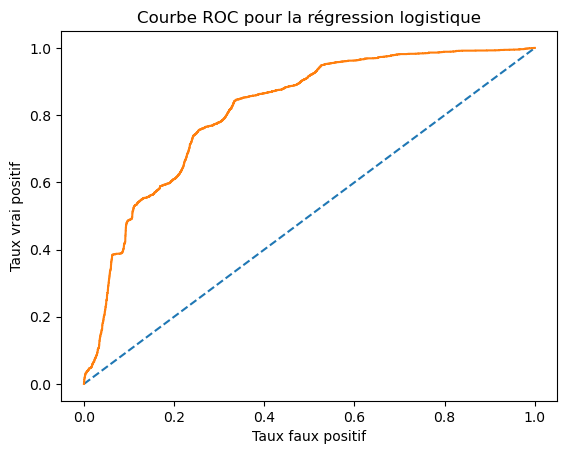

In [97]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_pred_prob = logreg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], '--')
plt.plot(fpr, tpr)
plt.xlabel('Taux faux positif')
plt.ylabel('Taux vrai positif')
plt.title('Courbe ROC pour la régression logistique')
plt.show()

In [98]:
from sklearn.metrics import roc_auc_score

y_pred_prob = logreg.predict_proba(X_test_scaled)[:, 1]
score_auc = roc_auc_score(y_test, y_pred_prob)
print(score_auc)

0.8138635312436899


**Modèle 4 : KNN**

In [99]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

params = [{"n_neighbors": 3}, {"n_neighbors": 5}, {"n_neighbors": 7}, {"n_neighbors": 11}, {"n_neighbors": 15}]

for p in params:
    knn = KNeighborsClassifier(**p)
    knn.fit(X_train_scaled, y_train)
    acc_train = accuracy_score(y_train, knn.predict(X_train_scaled))
    acc_test  = accuracy_score(y_test,  knn.predict(X_test_scaled))
    print(f"n_neighbors={p['n_neighbors']} : Train: {acc_train:.4f} | Test: {acc_test:.4f}")

n_neighbors=3 : Train: 0.8953 | Test: 0.8068
n_neighbors=5 : Train: 0.8711 | Test: 0.8132
n_neighbors=7 : Train: 0.8603 | Test: 0.8128
n_neighbors=11 : Train: 0.8483 | Test: 0.8164
n_neighbors=15 : Train: 0.8412 | Test: 0.8157


In [100]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid = {'n_neighbors': [3, 5, 7, 11, 15, 21]}
knn_cv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_cv.fit(X_train_scaled, y_train)

print("meilleur valeur d'hyperparamètre :", knn_cv.best_params_)
print("meilleur score :", knn_cv.best_score_)

meilleur valeur d'hyperparamètre : {'n_neighbors': 7}
meilleur score : 0.8226377295492486


In [101]:
import joblib
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN")
print("Accuracy:",  accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:",    recall_score(y_test, y_pred_knn))
print("F1-Score:",  f1_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

joblib.dump(knn, MODELS_DIR / "knn.joblib")
print("Modèle sauvegardé dans models/")

KNN
Accuracy: 0.812767094017094
Precision: 0.7113608992372541
Recall: 0.7217922606924644
F1-Score: 0.7165386170642943
[[4314  719]
 [ 683 1772]]
Modèle sauvegardé dans models/


**Modèle 5 : AdaBoost**

In [102]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

params = [{"n_estimators": 50}, {"n_estimators": 100}, {"n_estimators": 200}, {"n_estimators": 300}]

for p in params:
    ada = AdaBoostClassifier(**p, random_state=42)
    ada.fit(X_train_scaled, y_train)
    acc_train = accuracy_score(y_train, ada.predict(X_train_scaled))
    acc_test  = accuracy_score(y_test,  ada.predict(X_test_scaled))
    print(f"n_estimators={p['n_estimators']} : Train: {acc_train:.4f} | Test: {acc_test:.4f}")

n_estimators=50 : Train: 0.8134 | Test: 0.8181
n_estimators=100 : Train: 0.8355 | Test: 0.8392
n_estimators=200 : Train: 0.8402 | Test: 0.8399
n_estimators=300 : Train: 0.8423 | Test: 0.8409


In [103]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier

param_grid_ada = {'n_estimators': [100, 200, 300]}
ada_gs = GridSearchCV(AdaBoostClassifier(random_state=42), param_grid_ada, cv=3, scoring='accuracy', n_jobs=-1)
ada_gs.fit(X_train_scaled, y_train)
print("AdaBoost - Meilleurs paramètres :", ada_gs.best_params_)
print("Meilleur score CV :", round(ada_gs.best_score_, 4))
print("Score Test     :", round(ada_gs.score(X_test_scaled, y_test), 4))

AdaBoost - Meilleurs paramètres : {'n_estimators': 300}
Meilleur score CV : 0.8402
Score Test     : 0.8409


In [104]:
import joblib
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

ada = AdaBoostClassifier(n_estimators=300, random_state=42)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)

print("AdaBoost")
print("Accuracy:",  accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall:",    recall_score(y_test, y_pred_ada))
print("F1-Score:",  f1_score(y_test, y_pred_ada))
print(confusion_matrix(y_test, y_pred_ada))

joblib.dump(ada, MODELS_DIR / "adaboost.joblib")
print("Modèle sauvegardé dans models/")

AdaBoost
Accuracy: 0.8409455128205128
Precision: 0.7806394316163411
Recall: 0.7160896130346233
F1-Score: 0.7469725940089229
[[4539  494]
 [ 697 1758]]
Modèle sauvegardé dans models/


## 4 — Évaluation et comparaison


In [105]:
from sklearn.metrics import classification_report, confusion_matrix

print("Exemple d’usage après y_pred :")
print(classification_report.__doc__.split("\n")[0])

Exemple d’usage après y_pred :
Build a text report showing the main classification metrics.


             Modèle  Accuracy  Precision   Recall  F1-Score
      Random Forest  0.880475   0.856164 0.763747  0.807320
      Decision Tree  0.860310   0.822131 0.732383  0.774666
           AdaBoost  0.840946   0.780639 0.716090  0.746973
                KNN  0.812767   0.711361 0.721792  0.716539
Logistic Regression  0.752804   0.636899 0.572301  0.602875


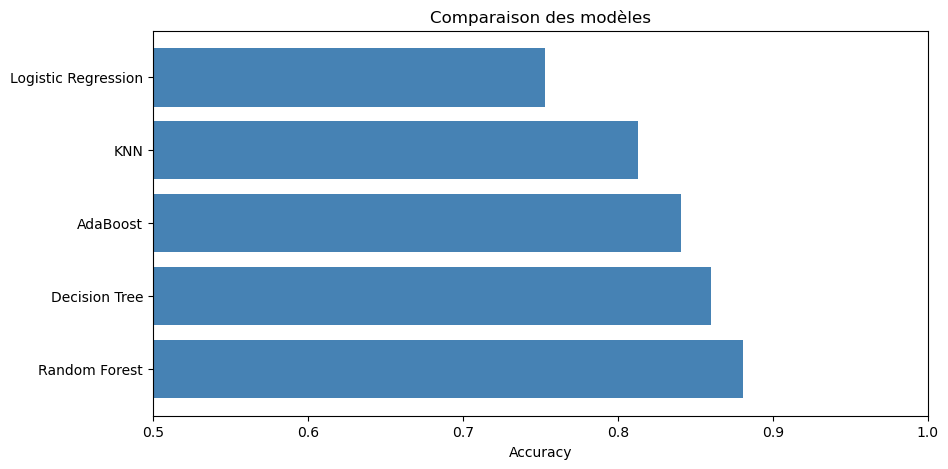

In [106]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

resultats = {
    'Modèle': ['Decision Tree', 'Random Forest', 'Logistic Regression', 'KNN', 'AdaBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_ada),
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_ada),
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_ada),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_ada),
    ]
}

df_resultats = pd.DataFrame(resultats).sort_values('Accuracy', ascending=False)
print(df_resultats.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(df_resultats['Modèle'], df_resultats['Accuracy'], color='steelblue')
plt.xlabel('Accuracy')
plt.title('Comparaison des modèles')
plt.xlim(0.5, 1.0)
plt.show()

**Matrice de corrélation**

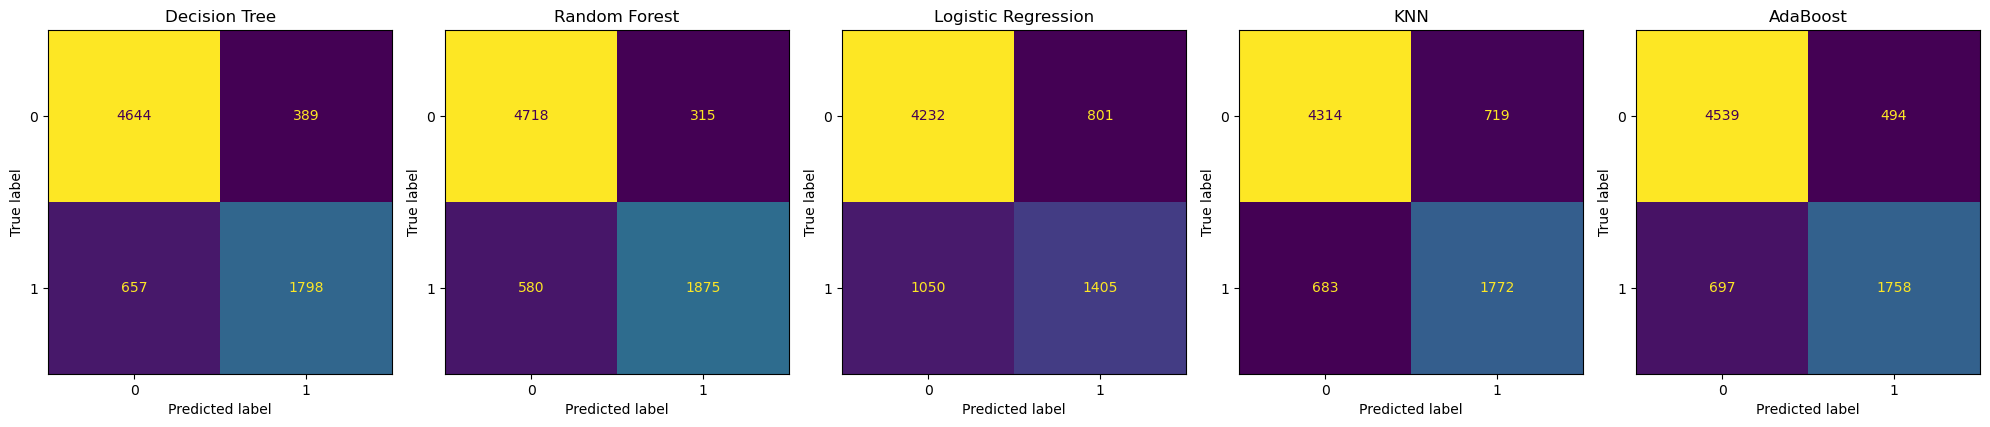

In [107]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (nom, y_pred) in zip(axes, [
    ("Decision Tree",       y_pred_dt),
    ("Random Forest",       y_pred_rf),
    ("Logistic Regression", y_pred_logreg),
    ("KNN",                 y_pred_knn),
    ("AdaBoost",            y_pred_ada),
]):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
    ax.set_title(nom)

plt.tight_layout()
plt.show()